In [10]:
import numpy as np
import matplotlib.pyplot as plt

#Step 1
x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([0, 1, 0, 1, 0, 1], dtype=float)

n = len(x)


# Step 2
h = np.zeros(n-1)
for i in range(n-1):
    h[i] = x[i+1] - x[i]

    
#Step 3
A = np.zeros(n)
B = np.zeros(n)
C = np.zeros(n)
D = np.zeros(n)

# Natural spline boundary conditions

In [11]:
B[0] = 1
B[-1] = 1

for i in range(1, n-1):
    A[i] = h[i-1]
    B[i] = 2*(h[i-1] + h[i])
    C[i] = h[i]
    D[i] = 6*((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1])

In [12]:
# Thomas Algorithm
for i in range(1, n):
    w = A[i] / B[i-1]
    B[i] = B[i] - w*C[i-1]
    D[i] = D[i] - w*D[i-1]

M = np.zeros(n)
M[-1] = D[-1] / B[-1]

for i in range(n-2, -1, -1):
    M[i] = (D[i] - C[i]*M[i+1]) / B[i]

In [13]:
# Step 4
def spline(x, y, M, x_eval):
    n = len(x)
    
    # Find the interval
    for i in range(n-1):
        if x[i] <= x_eval <= x[i+1]:
            break

    hi = x[i+1] - x[i]

    # Implementing the 4-term equation from the image
    term1 = (M[i] / (6*hi)) * (x[i+1] - x_eval)**3
    term2 = (M[i+1] / (6*hi)) * (x_eval - x[i])**3
    term3 = (y[i]/hi - M[i]*hi/6) * (x[i+1] - x_eval)
    term4 = (y[i+1]/hi - M[i+1]*hi/6) * (x_eval - x[i])

    return term1 + term2 + term3 + term4


x_plot = np.arange(x[0], x[-1] + 0.01, 0.01) # Fix applied here
y_plot = np.array([spline(x, y, M, val) for val in x_plot])


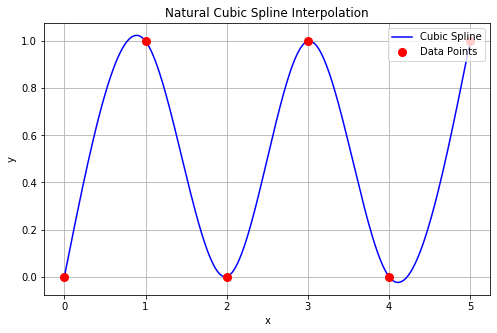

In [14]:

# Step 5
plt.figure(figsize=(8, 5))
plt.plot(x_plot, y_plot, label="Cubic Spline", color='blue')
plt.plot(x, y, 'o', label="Data Points", color='red', markersize=8)
plt.legend()
plt.grid(True)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Natural Cubic Spline Interpolation")
plt.show()

In [ ]:
Use chat